In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
etf = ['QQQ']
ticker = [
    'AAPL', 'MSFT', 'NVDA', 'AMZN', 'AVGO', 'META', 'NFLX', 'COST', 'TSLA', 'GOOGL',
    'GOOG', 'TMUS', 'PLTR', 'CSCO', 'LIN', 'PEP', 'ISRG', 'INTU', 'QCOM', 'BKNG',
    'ADBE', 'AMD', 'AMGN', 'TXN', 'GILD', 'HON', 'VRTX', 'CMCSA', 'AMAT', 'PANW',
    'ADP', 'MELI', 'CRWD', 'ADI', 'SBUX', 'KLAC', 'LRCX', 'INTC', 'APP', 'MSTR',
    'MU', 'MDLZ', 'CTAS', 'FTNT', 'ORLY', 'CDNS', 'PYPL', 'REGN', 'ROST', 'MRNA',
    'IDXX', 'WDAY', 'NXPI', 'ZS', 'MNST', 'SNPS', 'CHTR', 'MAR', 'PCAR', 'DLTR',
    'BIIB', 'ODFL', 'EXC', 'CSGP', 'FAST', 'KDP', 'TEAM', 'CPRT', 'TTD', 'XEL',
    'VRSK', 'ILMN', 'CEG', 'WBD', 'ANSS', 'ALGN', 'BKR', 'EBAY', 'CDW',
    'PAYX', 'SIRI', 'TTWO', 'VRSN', 'FANG', 'CTSH', 'ASML', 'DXCM', 'AZN', 'ZS',
    'MTCH', 'NTES', 'JD', 'BIDU', 'PDD', 'BMRN', 'EXPE','DOCU', 'ZM',
    'OKTA', 'TEAM', 'CRWD', 'DDOG', 'MDB', 'SNOW', 'QQQ'
]
data = yf.download(ticker, period='5y', interval='1d', auto_adjust=False)
data = data['Adj Close']


[*********************100%***********************]  102 of 102 completed

1 Failed download:
['ANSS']: YFPricesMissingError('possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")')


In [ ]:
def calculate_price_momentum_factors(data):
    momentum_factors = {}

    # Constants (convert weeks to trading days)
    days_52w = 252
    days_260 = 260
    days_4w = 20
    days_39w = 195
    days_51w = 255
    lag = 20

    for ticker in data.columns:
        prices = data[ticker].copy()

        #Slope of 52 Week Trend Line
        y = prices.shift(lag).rolling(days_52w).apply(
            lambda x: np.polyfit(range(len(x)), x, 1)[0], raw=True
        )

        #Percent Above 260 Day Low
        low_260 = prices.shift(lag).rolling(days_260).min()
        pct_above_260_low = (prices.shift(lag) - low_260) / low_260

        #4/52 Week Price Oscillator
        ma_4 = prices.shift(lag).rolling(days_4w).mean()
        ma_52 = prices.shift(lag).rolling(days_52w).mean()
        osc_4_52 = (ma_4 - ma_52) / ma_52

        #39 Week Return
        return_39w = prices.shift(lag) / prices.shift(lag + days_39w) - 1

        #51 Week Volume Price Trend
        daily_ret = prices.pct_change()
        price_trend = (prices.shift(1) * daily_ret).shift(lag).rolling(days_51w).sum()

        #Combine all into a DataFrame
        df = pd.DataFrame({
            'slope_52w': y,
            'pct_above_260_low': pct_above_260_low,
            'osc_4_52': osc_4_52,
            'return_39w': return_39w,
            'vpt_51w': price_trend
        })

        momentum_factors[ticker] = df

    #Combine into a MultiIndex DataFrame
    return pd.concat(momentum_factors, axis=1)

momentum_df = calculate_price_momentum_factors(data)


In [4]:
def compute_monthly_z_scores(momentum_df):
    #Resample to end of month
    monthly = momentum_df.resample('ME').last()

    #Swap column levels so we have (Factor, Ticker)
    monthly.columns = monthly.columns.swaplevel(0, 1)
    monthly = monthly.sort_index(axis=1) 

    #Z-score each factor across tickers for each month
    z = monthly.groupby(level=0, axis=1).transform(lambda x: (x - x.mean()) / x.std())

    #Compute composite z-score by averaging across all 5 factors per ticker
    composite_z = z.groupby(level=1, axis=1).mean()

    return z, composite_z

In [ ]:
z_scores, composite_z = compute_monthly_z_scores(momentum_df)


In [6]:
def get_long_short_baskets(composite_z, long_count=10, short_count=10):
    #Store long and short baskets
    long_baskets = {}
    short_baskets = {}

    #Rank assets by z-scores
    for date, row in composite_z.iterrows():
        ranked = row.dropna().sort_values(ascending=False)

        #Top assets for long and bottom assets for short 
        long_baskets[date] = ranked.head(long_count).index.tolist()
        short_baskets[date] = ranked.tail(short_count).index.tolist()

    return pd.Series(long_baskets), pd.Series(short_baskets)

In [7]:
long_basket, short_basket = get_long_short_baskets(composite_z, long_count=10, short_count=10)


In [8]:
def backtest_long_short_strategy(data, long_basket, short_basket):
    #Resample to month-end prices 
    monthly_prices = data.resample('ME').last()

    #Calculate monthly returns
    monthly_returns = monthly_prices.pct_change()

    portfolio_returns = []
    long_returns = []
    short_returns = []
    dates = []

    #Skip the first month 
    for date in long_basket.index[1:]:  
        longs = long_basket.loc[date]
        shorts = short_basket.loc[date]

        try:
            long_ret = monthly_returns.loc[date, longs].mean() #Avg return of long basket
            short_ret = monthly_returns.loc[date, shorts].mean() #Avg return of short basket
            net_ret = long_ret - short_ret #Long-short return 
        except Exception as e:
            print(f"Skipping {date} due to error: {e}") #Missing data or errors 
            continue

        long_returns.append(long_ret)
        short_returns.append(short_ret)
        portfolio_returns.append(net_ret)
        dates.append(date)

    #Results into dataframe 
    results = pd.DataFrame({
        'Long': long_returns,
        'Short': short_returns,
        'Long-Short': portfolio_returns
    }, index=dates)

    #Calculate cumulative returns 
    results['Cumulative Long'] = (1 + results['Long']).cumprod()
    results['Cumulative Short'] = (1 + results['Short']).cumprod()
    results['Cumulative Long-Short'] = (1 + results['Long-Short']).cumprod()
    
    #QQQ benchmark 
    results['QQQ'] = monthly_returns['QQQ'].loc[results.index]
    results['Cumulative QQQ'] = (1 + results['QQQ']).cumprod()

    return results

In [ ]:
results = backtest_long_short_strategy(data, long_basket, short_basket)


In [10]:
def plot_monthly_returns_vs_etf(results, strategy_col='Long-Short', etf_col='QQQ'):
    plt.figure(figsize=(14, 6))

    #Color bars green for positve, red for negative 
    colors = ['green' if x >= 0 else 'red' for x in results[strategy_col]]

    #Bar chart for strategy returns 
    plt.bar(results.index, results[strategy_col], color=colors, label='Long-Short Strategy', width=20)

    #Line plot for ETF returns 
    plt.plot(results.index, results[etf_col], color='blue', linewidth=2, label=f'{etf_col} Monthly Return')

    plt.axhline(0, color='black', linewidth=0.8)
    plt.title(f'Monthly Portfolio Return vs {etf_col}')
    plt.ylabel('Monthly Return')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

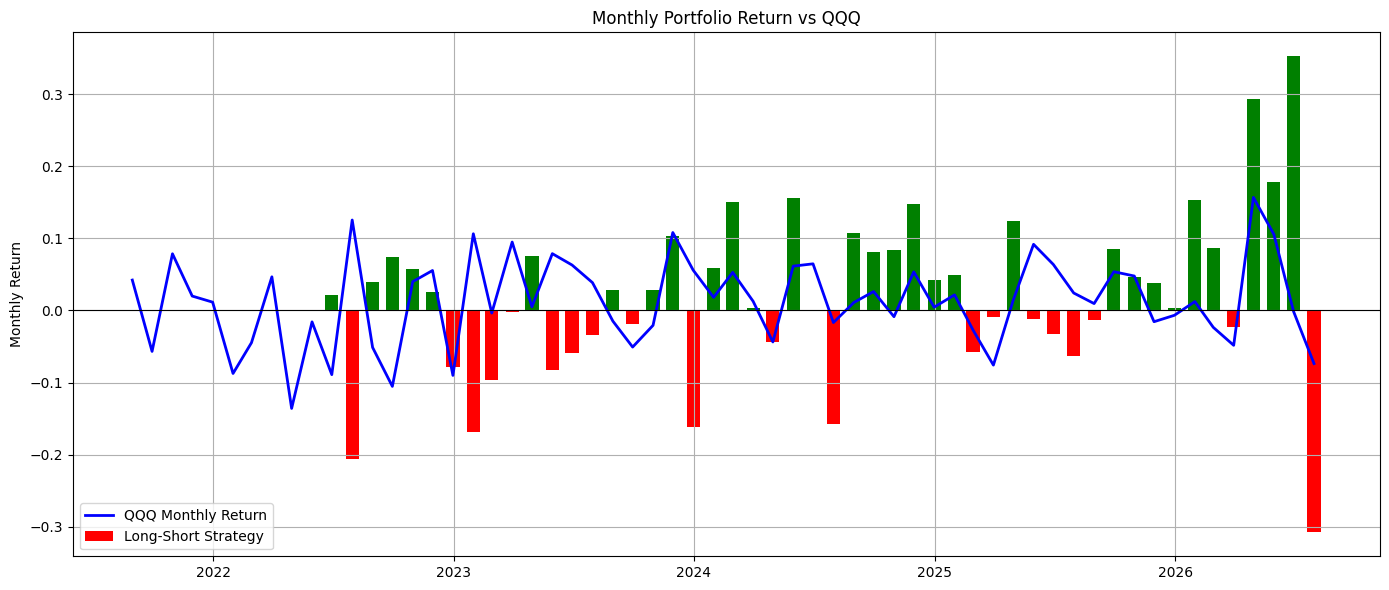

In [11]:
plot_monthly_returns_vs_etf(results, strategy_col='Long-Short', etf_col='QQQ')


In [12]:
def plot_monthly_long_short_vs_etf(results):
    plt.figure(figsize=(14, 6))

    #Line plots for monthly returns of long, short, and ETF
    plt.plot(results.index, results['Long'], color='green', linewidth=2, label='Long Picks')
    plt.plot(results.index, results['Short'], color='red', linewidth=2, label='Short Picks')
    plt.plot(results.index, results['QQQ'], color='blue', linewidth=2, label='QQQ ETF')

    plt.axhline(0, color='black', linewidth=0.8)
    plt.title('Monthly Returns: Long Picks vs Short Picks vs QQQ ETF')
    plt.ylabel('Monthly Return')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

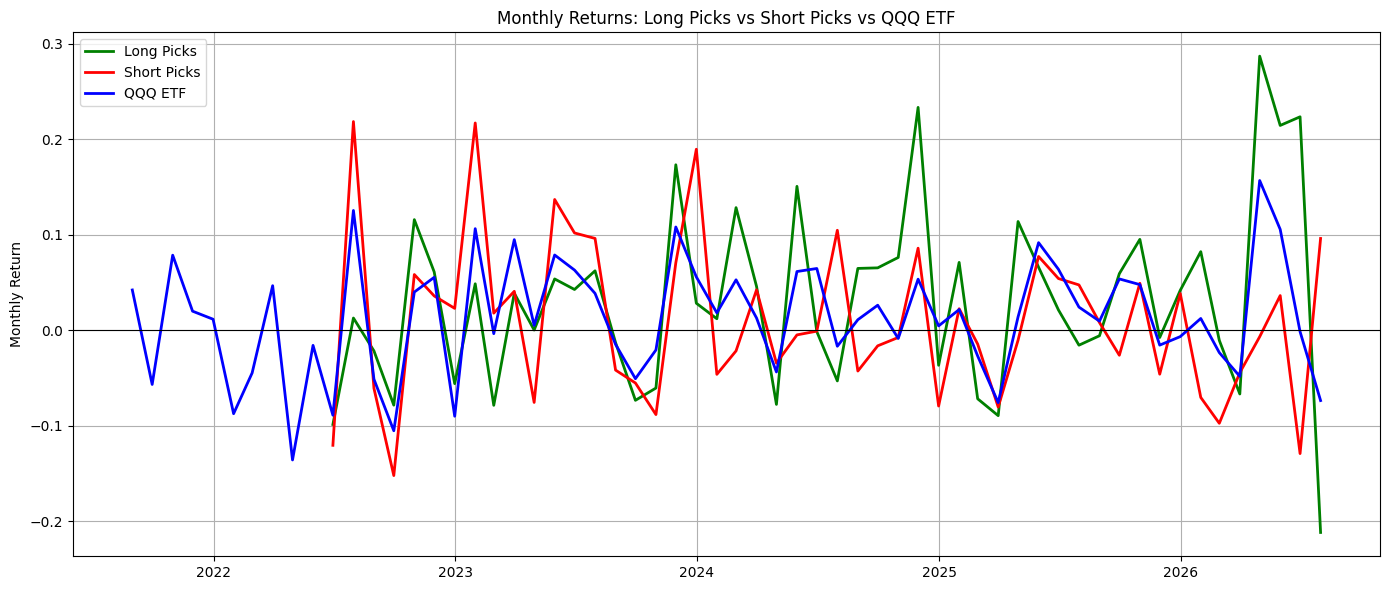

In [13]:
plot_monthly_long_short_vs_etf(results)

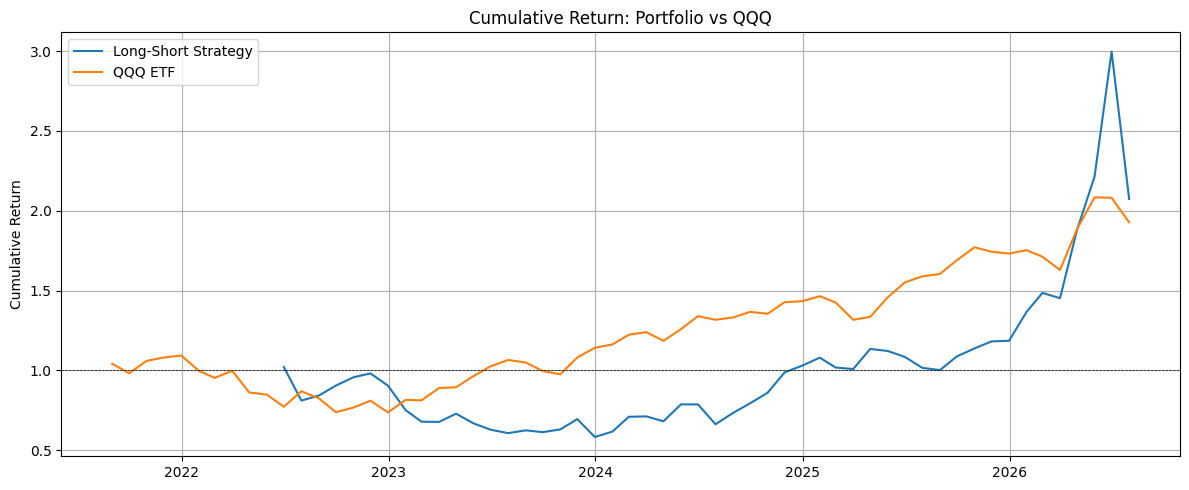

In [14]:
## Plot cumulative returns of long-short strategy and QQQ ETF
plt.figure(figsize=(12, 5))
plt.plot(results.index, results['Cumulative Long-Short'], label='Long-Short Strategy')
plt.plot(results.index, results['Cumulative QQQ'], label='QQQ ETF')
plt.title('Cumulative Return: Portfolio vs QQQ')
plt.ylabel('Cumulative Return')
plt.axhline(1.0, color='black', linestyle='--', linewidth=0.5)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()